使用设备: cuda
训练集: 60000  测试集: 10000
输入形状: torch.Size([1, 28, 28])
MNIST_CNN(
  (conv_layers): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fc_layers): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=3136, out_features=128, bias=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=10, bias=True)
  )
)


Epoch 1/10: 100%|██████████| 938/938 [00:13<00:00, 71.14it/s, loss=0.0032] 


  Loss: 0.1319  |  测试准确率: 98.60%


Epoch 2/10: 100%|██████████| 938/938 [00:19<00:00, 47.25it/s, loss=0.033]   


  Loss: 0.0426  |  测试准确率: 98.79%


...

  Loss: 0.0081  |  测试准确率: 99.13%


Epoch 9/10: 100%|██████████| 938/938 [00:16<00:00, 57.63it/s, loss=2.24e-6] 


  Loss: 0.0082  |  测试准确率: 99.05%


Epoch 10/10: 100%|██████████| 938/938 [00:15<00:00, 61.02it/s, loss=0.000449]


  Loss: 0.0054  |  测试准确率: 98.94%


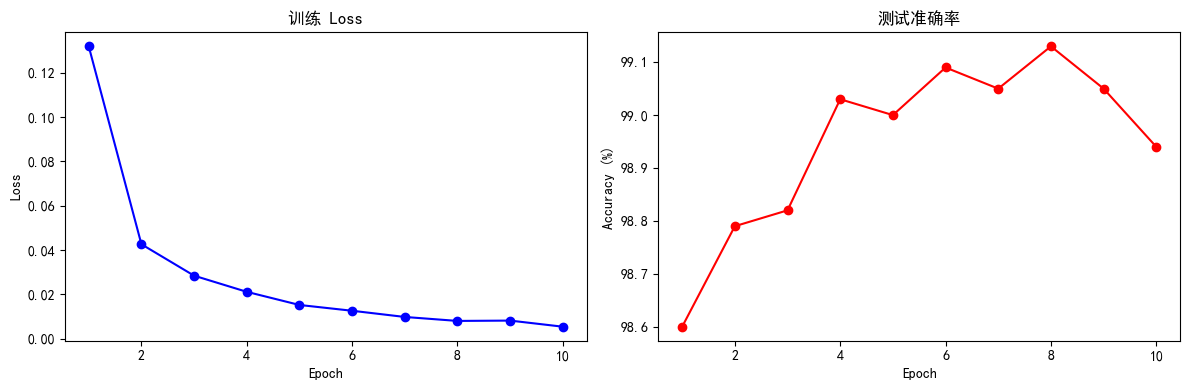


🎉 最终测试准确率: 98.94%


In [1]:
# ============================================================
# CNN 训练 MNIST 手写数字识别
# ============================================================

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from tqdm import tqdm
import matplotlib.pyplot as plt

plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'SimSun']
plt.rcParams['axes.unicode_minus'] = False

# ---------- 设备 ----------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"使用设备: {device}")

# ---------- 数据加载 ----------
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))  # MNIST 全局均值和标准差
])

data_dir = r"D:\Medicaldata"
train_dataset = datasets.MNIST(root=data_dir, train=True, download=True, transform=transform)
test_dataset  = datasets.MNIST(root=data_dir, train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=64, shuffle=False)

print(f"训练集: {len(train_dataset)}  测试集: {len(test_dataset)}")
print(f"输入形状: {train_dataset[0][0].shape}")

# ---------- CNN 网络定义 ----------
class MNIST_CNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv_layers = nn.Sequential(
            # Conv1: 1x28x28 -> 32x14x14
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            # Conv2: 32x14x14 -> 64x7x7
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )
        self.fc_layers = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 7 * 7, 128),
            nn.ReLU(),
            nn.Linear(128, 10),
        )

    def forward(self, x):
        x = self.conv_layers(x)
        x = self.fc_layers(x)
        return x

net = MNIST_CNN().to(device)
print(net)

# ---------- 训练配置 ----------
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(net.parameters(), lr=0.001)
num_epochs = 10

train_losses, test_accs = [], []

# ---------- 训练循环 ----------
for epoch in range(1, num_epochs + 1):
    net.train()
    running_loss = 0.0
    pbar = tqdm(train_loader, desc=f"Epoch {epoch}/{num_epochs}")

    for inputs, labels in pbar:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = net(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * inputs.size(0)
        pbar.set_postfix(loss=loss.item())

    avg_loss = running_loss / len(train_dataset)
    train_losses.append(avg_loss)

    # 测试
    net.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = net(inputs)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

    acc = 100.0 * correct / total
    test_accs.append(acc)
    print(f"  Loss: {avg_loss:.4f}  |  测试准确率: {acc:.2f}%")

# ---------- 结果曲线 ----------
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(range(1, num_epochs + 1), train_losses, 'b-o')
plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.title('训练 Loss')

plt.subplot(1, 2, 2)
plt.plot(range(1, num_epochs + 1), test_accs, 'r-o')
plt.xlabel('Epoch'); plt.ylabel('Accuracy (%)'); plt.title('测试准确率')

plt.tight_layout()
plt.show()

print(f"\n🎉 最终测试准确率: {test_accs[-1]:.2f}%")


使用设备: cuda
训练集: 60000  测试集: 10000
输入形状: torch.Size([1, 32, 32])
LeNet5(
  (features): Sequential(
    (0): Conv2d(1, 6, kernel_size=(5, 5), stride=(1, 1))
    (1): Tanh()
    (2): AvgPool2d(kernel_size=2, stride=2, padding=0)
    (3): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
    (4): Tanh()
    (5): AvgPool2d(kernel_size=2, stride=2, padding=0)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=400, out_features=120, bias=True)
    (2): Tanh()
    (3): Linear(in_features=120, out_features=84, bias=True)
    (4): Tanh()
    (5): Linear(in_features=84, out_features=10, bias=True)
  )
)


Epoch 1/10: 100%|██████████| 938/938 [00:20<00:00, 44.92it/s, loss=0.0705] 


  Loss: 0.2252  |  测试准确率: 97.82%


Epoch 2/10: 100%|██████████| 938/938 [00:16<00:00, 55.27it/s, loss=0.0146] 


  Loss: 0.0713  |  测试准确率: 98.40%


...

  Loss: 0.0182  |  测试准确率: 98.81%


Epoch 9/10: 100%|██████████| 938/938 [00:17<00:00, 53.27it/s, loss=0.00245] 


  Loss: 0.0185  |  测试准确率: 98.88%


Epoch 10/10: 100%|██████████| 938/938 [00:17<00:00, 54.68it/s, loss=0.0816]  


  Loss: 0.0148  |  测试准确率: 98.80%


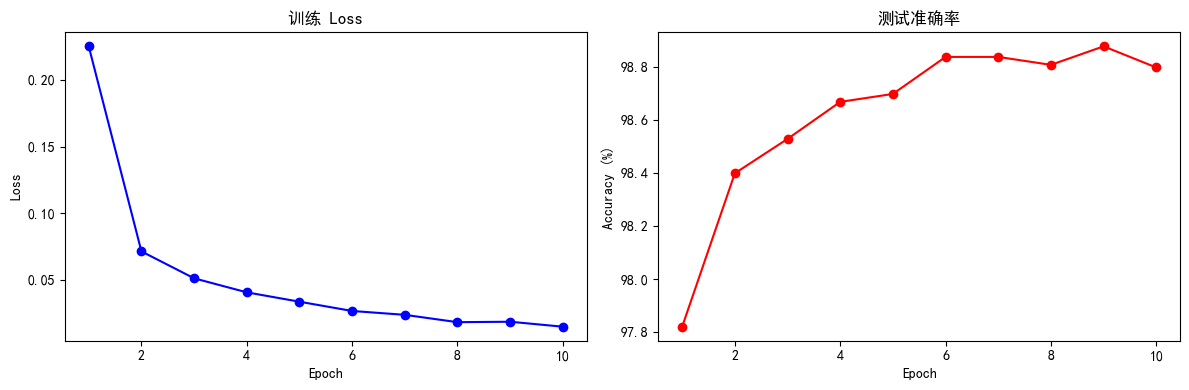


🎉 LeNet 最终测试准确率: 98.80%


In [2]:
# ============================================================
# 经典 LeNet-5 训练 MNIST 手写数字识别
# ============================================================

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from tqdm import tqdm
import matplotlib.pyplot as plt

plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'SimSun']
plt.rcParams['axes.unicode_minus'] = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"使用设备: {device}")

# ---------- 数据加载（LeNet 输入要求 32x32，需要 resize） ----------
train_transform = transforms.Compose([
    transforms.Resize(32),        # MNIST 28x28 → 32x32（LeNet 原始设计）
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

test_transform = transforms.Compose([
    transforms.Resize(32),
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

data_dir = r"D:\Medicaldata"
train_dataset = datasets.MNIST(root=data_dir, train=True, download=True, transform=train_transform)
test_dataset  = datasets.MNIST(root=data_dir, train=False, download=True, transform=test_transform)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=64, shuffle=False)

print(f"训练集: {len(train_dataset)}  测试集: {len(test_dataset)}")
print(f"输入形状: {train_dataset[0][0].shape}")

# ============================================================
# LeNet-5 网络结构（1998年 Yann LeCun 提出）
# 论文: Gradient-Based Learning Applied to Document Recognition
# ============================================================
class LeNet5(nn.Module):
    def __init__(self):
        super().__init__()
        # 卷积特征提取层
        self.features = nn.Sequential(
            # C1: 1x32x32 -> 6x28x28
            nn.Conv2d(1, 6, kernel_size=5),        # 5x5 卷积核，无填充
            nn.Tanh(),                               # LeNet 原版用 Tanh（当时 ReLU 还没普及）
            nn.AvgPool2d(kernel_size=2, stride=2),   # S2: 6x28x28 -> 6x14x14（平均池化）

            # C3: 6x14x14 -> 16x10x10
            nn.Conv2d(6, 16, kernel_size=5),        # 5x5 卷积核
            nn.Tanh(),
            nn.AvgPool2d(kernel_size=2, stride=2),   # S4: 16x10x10 -> 16x5x5
        )
        # 全连接分类层
        self.classifier = nn.Sequential(
            nn.Flatten(),
            # C5: 16x5x5=400 -> 120（原版用卷积，这里用全连接等价）
            nn.Linear(16 * 5 * 5, 120),
            nn.Tanh(),
            # F6: 120 -> 84
            nn.Linear(120, 84),
            nn.Tanh(),
            # 输出: 84 -> 10（原版用欧式径向基，这里用常规全连接）
            nn.Linear(84, 10),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

net = LeNet5().to(device)
print(net)

# ---------- 训练配置 ----------
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(net.parameters(), lr=0.001)
num_epochs = 10

train_losses, test_accs = [], []

for epoch in range(1, num_epochs + 1):
    net.train()
    running_loss = 0.0
    pbar = tqdm(train_loader, desc=f"Epoch {epoch}/{num_epochs}")

    for inputs, labels in pbar:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = net(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * inputs.size(0)
        pbar.set_postfix(loss=loss.item())

    avg_loss = running_loss / len(train_dataset)
    train_losses.append(avg_loss)

    net.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = net(inputs)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

    acc = 100.0 * correct / total
    test_accs.append(acc)
    print(f"  Loss: {avg_loss:.4f}  |  测试准确率: {acc:.2f}%")

# ---------- 结果曲线 ----------
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(range(1, num_epochs + 1), train_losses, 'b-o')
plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.title('训练 Loss')

plt.subplot(1, 2, 2)
plt.plot(range(1, num_epochs + 1), test_accs, 'r-o')
plt.xlabel('Epoch'); plt.ylabel('Accuracy (%)'); plt.title('测试准确率')

plt.tight_layout()
plt.show()

print(f"\n🎉 LeNet 最终测试准确率: {test_accs[-1]:.2f}%")
